In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

os.makedirs("reports", exist_ok=True)

print("✅ Libraries imported!")

nav_history = pd.read_csv("data/processed/nav_history_clean.csv")
fund_master = pd.read_csv("data/processed/fund_master_clean.csv")
live_nav = pd.read_csv("data/processed/live_nav_clean.csv")

nav_history['Date'] = pd.to_datetime(nav_history['Date'])

print("✅ Data loaded!")
print("nav_history shape:", nav_history.shape)
print(nav_history.head())

ModuleNotFoundError: No module named 'plotly'

In [2]:
import subprocess
subprocess.run(['pip', 'install', 'plotly'])
print("✅ Plotly installed!")

✅ Plotly installed!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

os.makedirs("reports", exist_ok=True)

print("✅ Libraries imported!")

nav_history = pd.read_csv("data/processed/nav_history_clean.csv")
fund_master = pd.read_csv("data/processed/fund_master_clean.csv")
live_nav = pd.read_csv("data/processed/live_nav_clean.csv")

nav_history['Date'] = pd.to_datetime(nav_history['Date'])

print("✅ Data loaded!")
print("nav_history shape:", nav_history.shape)
print(nav_history.head())

✅ Libraries imported!
✅ Data loaded!
nav_history shape: (150, 4)
        Date            Scheme    Code       NAV
0 2026-04-17  Nippon Large Cap  118632  100.7903
1 2026-04-20  Nippon Large Cap  118632  100.9566
2 2026-04-21  Nippon Large Cap  118632  101.9645
3 2026-04-22  Nippon Large Cap  118632  101.5803
4 2026-04-23  Nippon Large Cap  118632  100.8016


In [ ]:
NAV Trend Analysis

=== CHART 1: NAV TREND ANALYSIS ===


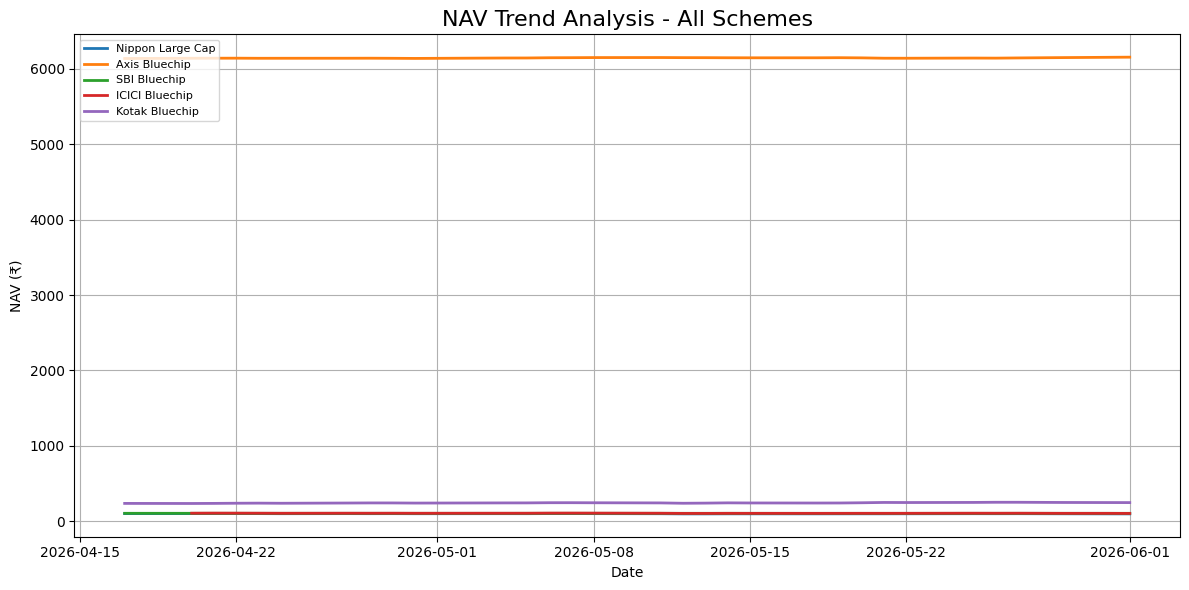

✅ Chart 1 saved!


In [4]:
print("=== CHART 1: NAV TREND ANALYSIS ===")

plt.figure(figsize=(12, 6))

for scheme in nav_history['Scheme'].unique():
    scheme_data = nav_history[nav_history['Scheme'] == scheme]
    plt.plot(scheme_data['Date'], 
             scheme_data['NAV'], 
             label=scheme, 
             linewidth=2)

plt.title('NAV Trend Analysis - All Schemes', fontsize=16)
plt.xlabel('Date')
plt.ylabel('NAV (₹)')
plt.legend(loc='upper left', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig('reports/chart1_nav_trend.png', dpi=150)
plt.show()

print("✅ Chart 1 saved!")

In [ ]:
Latest NAV Bar Chart

=== CHART 2: LATEST NAV COMPARISON ===


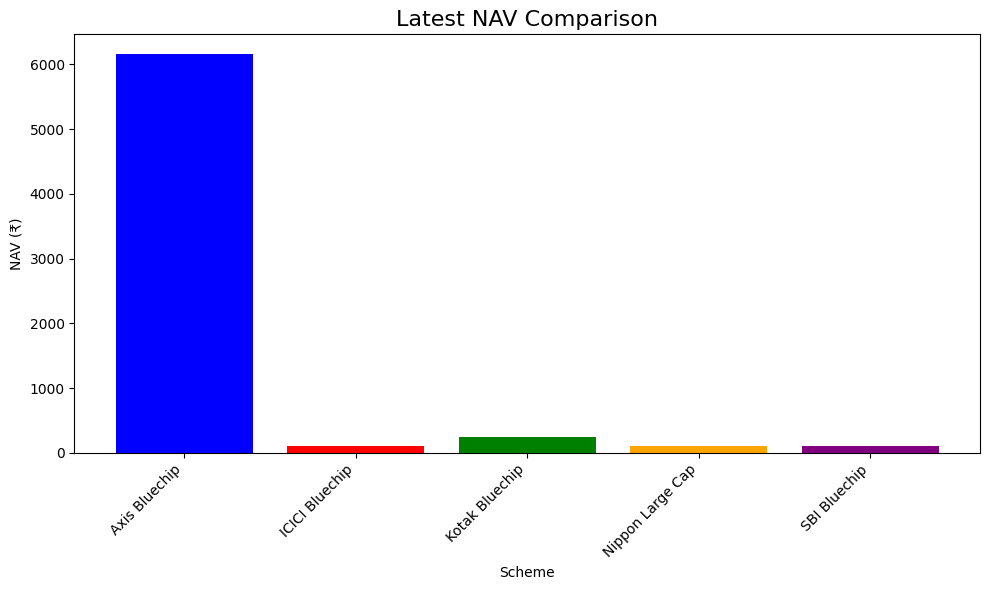

✅ Chart 2 saved!


In [5]:
print("=== CHART 2: LATEST NAV COMPARISON ===")

latest_nav = nav_history.groupby('Scheme')['NAV'].last().reset_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(latest_nav['Scheme'], 
               latest_nav['NAV'], 
               color=['blue','red','green','orange','purple'])

plt.title('Latest NAV Comparison', fontsize=16)
plt.xlabel('Scheme')
plt.ylabel('NAV (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('reports/chart2_latest_nav.png', dpi=150)
plt.show()

print("✅ Chart 2 saved!")

In [ ]:
NAV Distribution Box Plot

=== CHART 3: NAV DISTRIBUTION ===


<Figure size 1200x600 with 0 Axes>

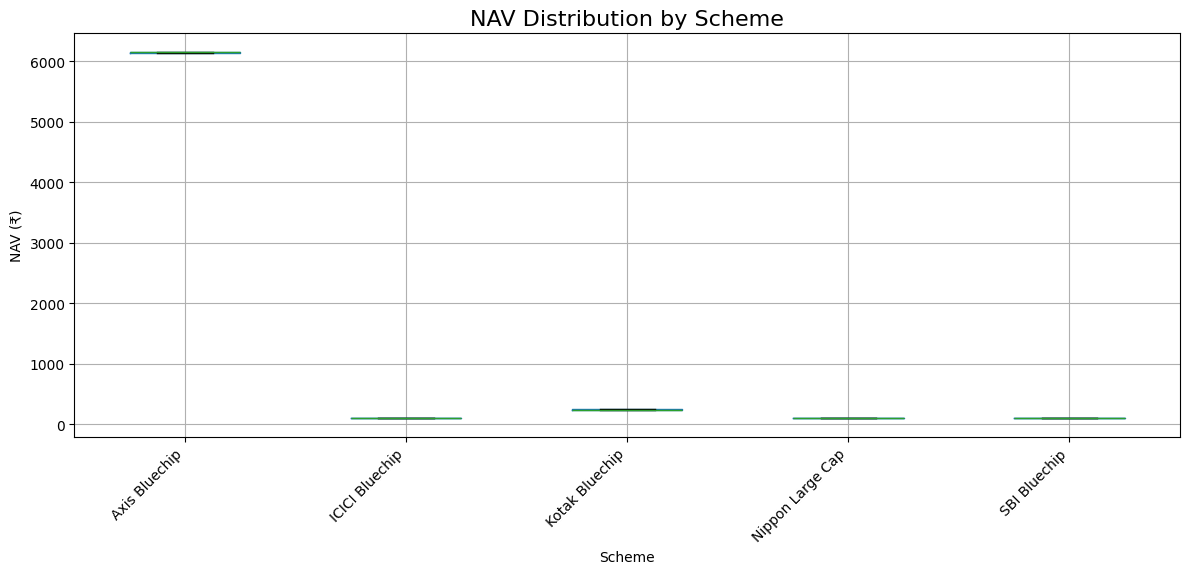

✅ Chart 3 saved!


In [6]:
print("=== CHART 3: NAV DISTRIBUTION ===")

plt.figure(figsize=(12, 6))
nav_history.boxplot(column='NAV', by='Scheme', figsize=(12,6))
plt.title('NAV Distribution by Scheme', fontsize=16)
plt.suptitle('')
plt.xlabel('Scheme')
plt.ylabel('NAV (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('reports/chart3_nav_distribution.png', dpi=150)
plt.show()

print("✅ Chart 3 saved!")

In [ ]:
NAV Heatmap

=== CHART 4: NAV CORRELATION HEATMAP ===


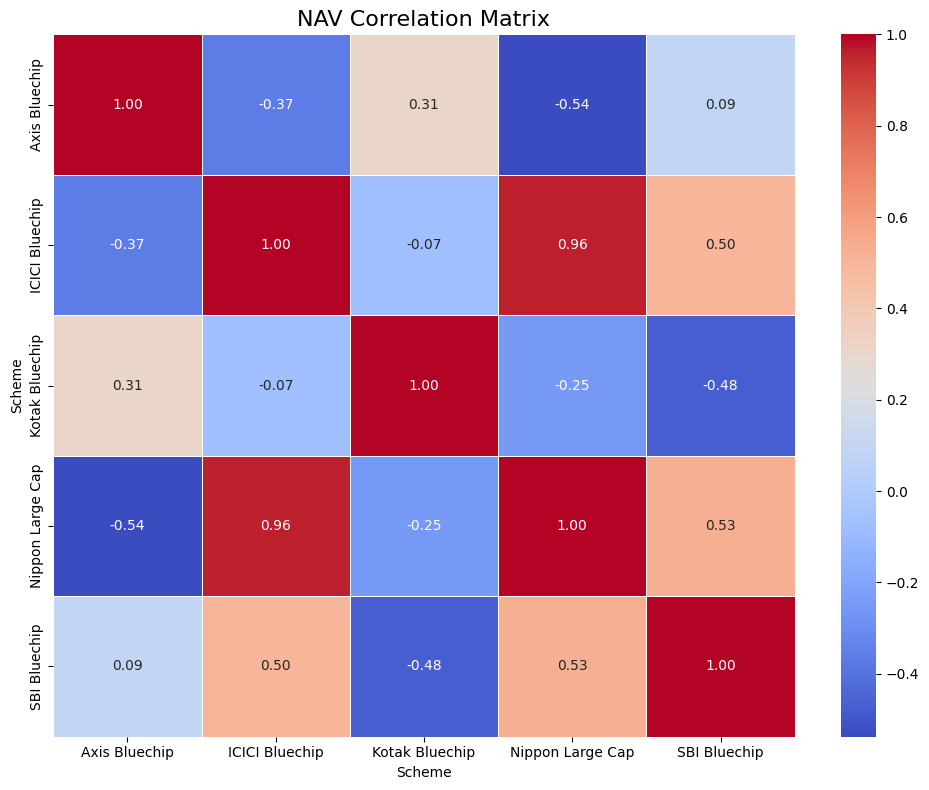

✅ Chart 4 saved!


In [7]:
print("=== CHART 4: NAV CORRELATION HEATMAP ===")

# Pivot table
nav_pivot = nav_history.pivot_table(
    index='Date', 
    columns='Scheme', 
    values='NAV'
)

corr_matrix = nav_pivot.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)
plt.title('NAV Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.savefig('reports/chart4_correlation_heatmap.png', dpi=150)
plt.show()

print("✅ Chart 4 saved!")

In [ ]:
NAV Returns Analysis

=== CHART 5: NAV DAILY RETURNS ===


C:\Users\Admin\AppData\Local\Temp\ipykernel_11616\858942155.py:9: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = nav_pivot.pct_change().dropna()


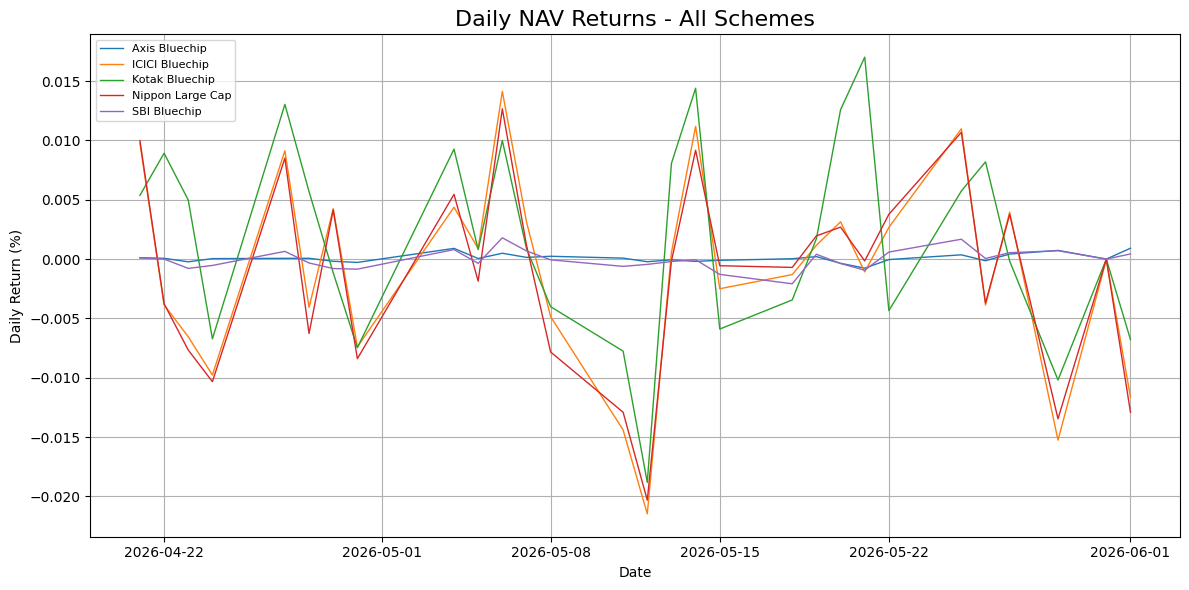

✅ Chart 5 saved!


In [8]:
print("=== CHART 5: NAV DAILY RETURNS ===")

# Calculate daily returns
nav_pivot = nav_history.pivot_table(
    index='Date', 
    columns='Scheme', 
    values='NAV'
)
daily_returns = nav_pivot.pct_change().dropna()

plt.figure(figsize=(12, 6))
for column in daily_returns.columns:
    plt.plot(daily_returns.index, 
             daily_returns[column], 
             label=column, 
             linewidth=1)

plt.title('Daily NAV Returns - All Schemes', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.legend(loc='upper left', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig('reports/chart5_daily_returns.png', dpi=150)
plt.show()

print("✅ Chart 5 saved!")

In [ ]:
NAV Growth

=== CHART 6: NAV GROWTH % ===


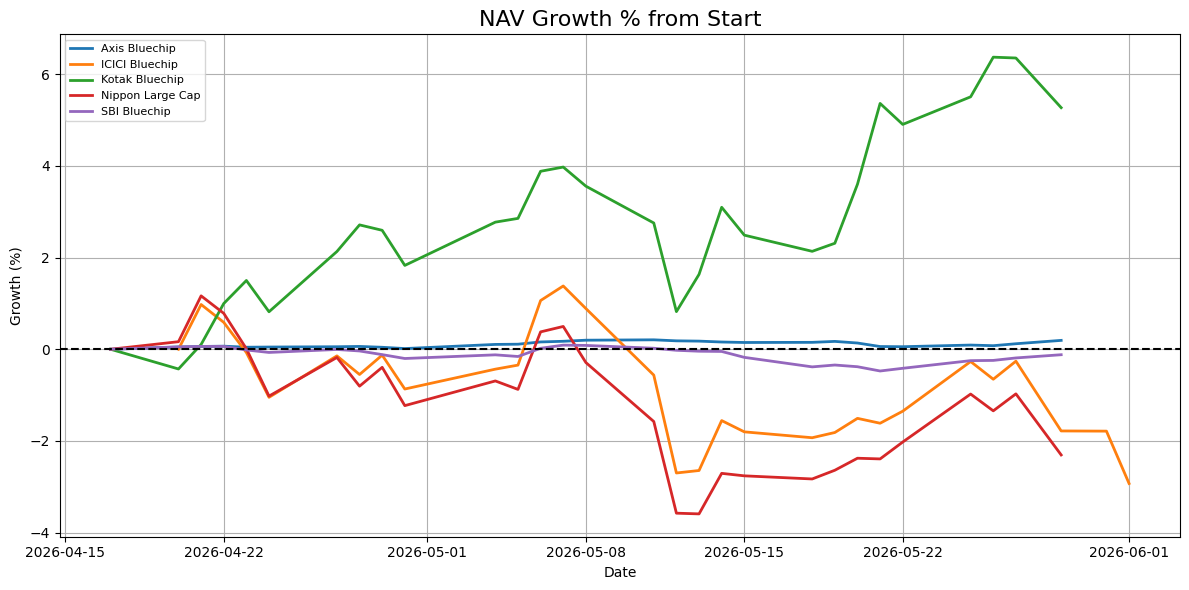

✅ Chart 6 saved!


In [9]:
print("=== CHART 6: NAV GROWTH % ===")

# Calculate growth from first NAV
nav_growth = nav_pivot.copy()
for col in nav_growth.columns:
    first_val = nav_growth[col].dropna().iloc[0]
    nav_growth[col] = ((nav_growth[col] - first_val) / first_val) * 100

plt.figure(figsize=(12, 6))
for column in nav_growth.columns:
    plt.plot(nav_growth.index,
             nav_growth[column],
             label=column,
             linewidth=2)

plt.title('NAV Growth % from Start', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Growth (%)')
plt.legend(loc='upper left', fontsize=8)
plt.grid(True)
plt.axhline(y=0, color='black', linestyle='--')
plt.tight_layout()
plt.savefig('reports/chart6_nav_growth.png', dpi=150)
plt.show()

print("✅ Chart 6 saved!")

In [ ]:
Average NAV Bar Chart

=== CHART 7: AVERAGE NAV PER SCHEME ===


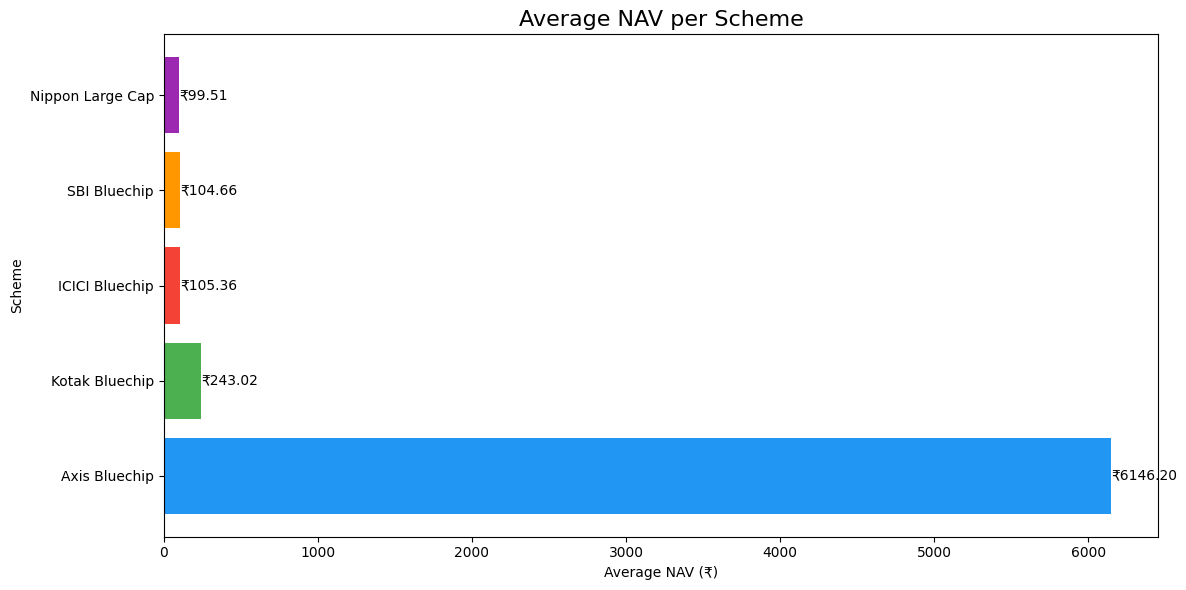

✅ Chart 7 saved!


In [10]:
print("=== CHART 7: AVERAGE NAV PER SCHEME ===")

avg_nav = nav_history.groupby('Scheme')['NAV'].mean().reset_index()
avg_nav.columns = ['Scheme', 'Avg_NAV']
avg_nav = avg_nav.sort_values('Avg_NAV', ascending=False)

plt.figure(figsize=(12, 6))
colors = ['#2196F3','#4CAF50','#F44336','#FF9800','#9C27B0']
bars = plt.barh(avg_nav['Scheme'], 
                avg_nav['Avg_NAV'],
                color=colors)

plt.title('Average NAV per Scheme', fontsize=16)
plt.xlabel('Average NAV (₹)')
plt.ylabel('Scheme')

# Add value labels
for bar, val in zip(bars, avg_nav['Avg_NAV']):
    plt.text(bar.get_width(), 
             bar.get_y() + bar.get_height()/2,
             f'₹{val:.2f}',
             va='center', fontsize=10)

plt.tight_layout()
plt.savefig('reports/chart7_avg_nav.png', dpi=150)
plt.show()

print("✅ Chart 7 saved!")

In [ ]:
NAV Pie Chart

=== CHART 8: NAV SHARE PIE CHART ===


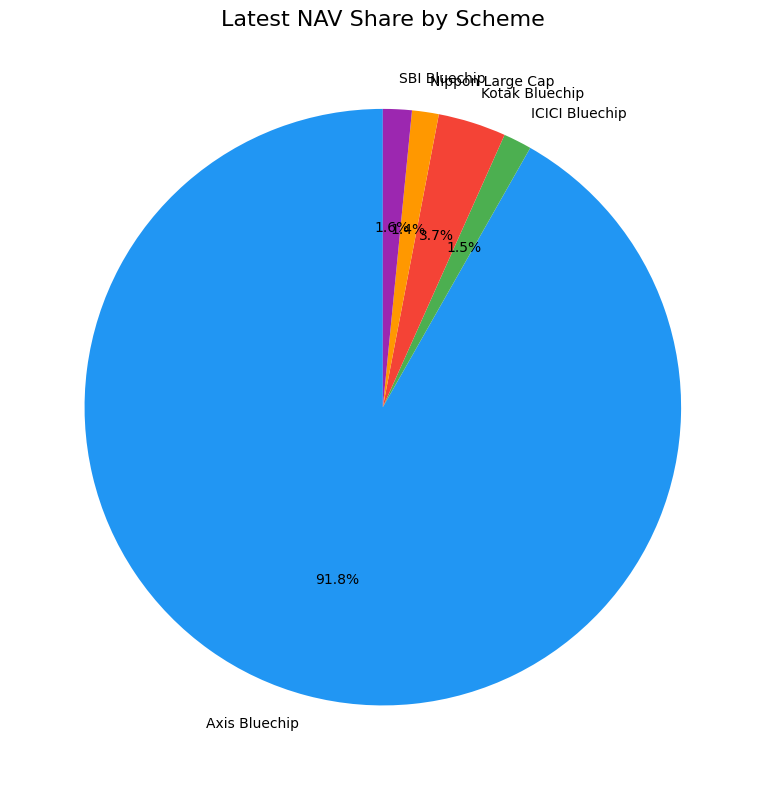

✅ Chart 8 saved!


In [11]:
print("=== CHART 8: NAV SHARE PIE CHART ===")

latest = nav_history.groupby('Scheme')['NAV'].last()

plt.figure(figsize=(10, 8))
plt.pie(latest.values,
        labels=latest.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['#2196F3','#4CAF50',
                '#F44336','#FF9800','#9C27B0'])

plt.title('Latest NAV Share by Scheme', fontsize=16)
plt.tight_layout()
plt.savefig('reports/chart8_nav_pie.png', dpi=150)
plt.show()

print("✅ Chart 8 saved!")

In [ ]:
NAV Volatility Analysis

=== CHART 9: NAV VOLATILITY ===


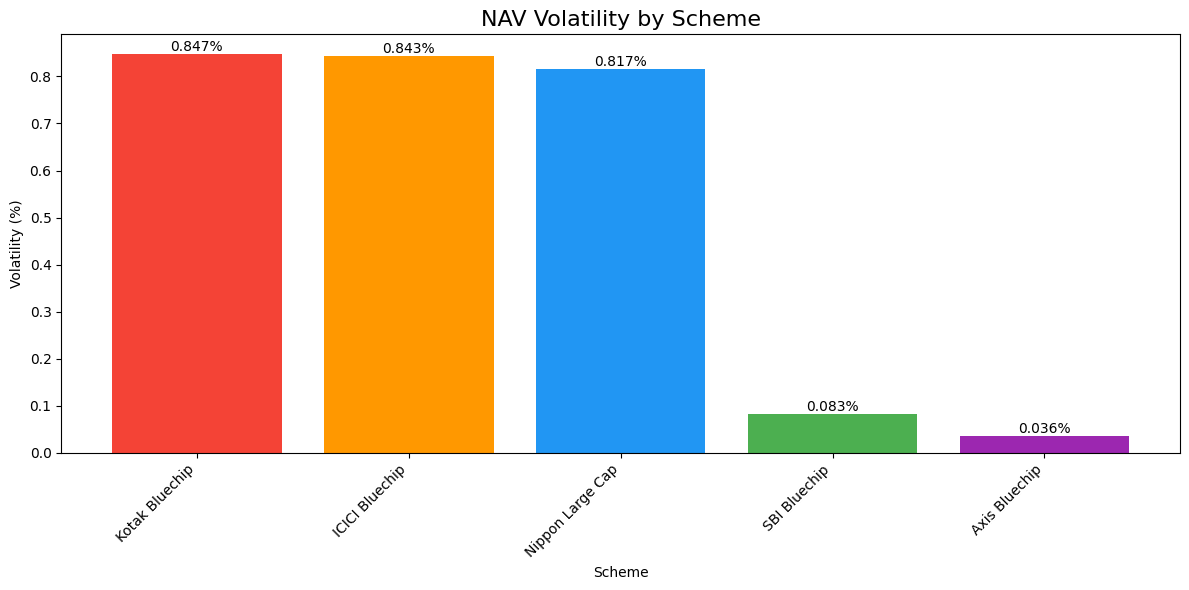

✅ Chart 9 saved!


In [12]:
print("=== CHART 9: NAV VOLATILITY ===")

# Calculate volatility (std dev of returns)
volatility = daily_returns.std() * 100
volatility = volatility.reset_index()
volatility.columns = ['Scheme', 'Volatility']
volatility = volatility.sort_values('Volatility', ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(volatility['Scheme'],
               volatility['Volatility'],
               color=['#F44336','#FF9800',
                      '#2196F3','#4CAF50','#9C27B0'])

plt.title('NAV Volatility by Scheme', fontsize=16)
plt.xlabel('Scheme')
plt.ylabel('Volatility (%)')
plt.xticks(rotation=45, ha='right')

# Add value labels
for bar, val in zip(bars, volatility['Volatility']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{val:.3f}%',
             ha='center', va='bottom')

plt.tight_layout()
plt.savefig('reports/chart9_volatility.png', dpi=150)
plt.show()

print("✅ Chart 9 saved!")

In [ ]:
Min Max NAV

=== CHART 10: MIN MAX NAV ===


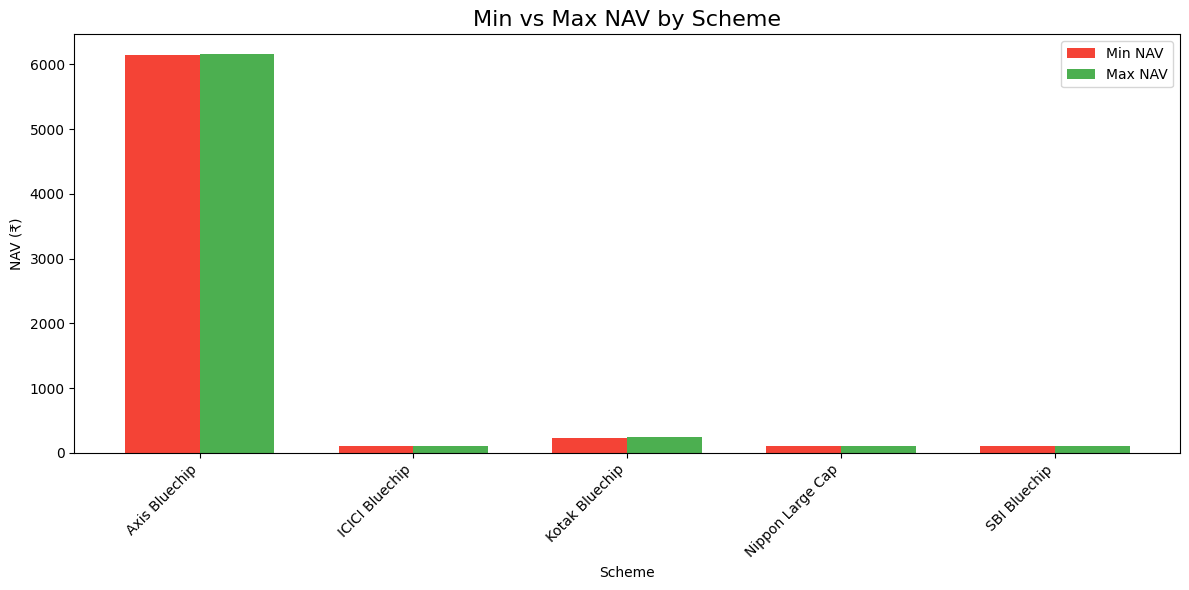

✅ Chart 10 saved!


In [13]:
print("=== CHART 10: MIN MAX NAV ===")

min_nav = nav_history.groupby('Scheme')['NAV'].min()
max_nav = nav_history.groupby('Scheme')['NAV'].max()

x = range(len(min_nav))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar([i - width/2 for i in x],
               min_nav.values,
               width, label='Min NAV',
               color='#F44336')
bars2 = ax.bar([i + width/2 for i in x],
               max_nav.values,
               width, label='Max NAV',
               color='#4CAF50')

ax.set_title('Min vs Max NAV by Scheme', fontsize=16)
ax.set_xlabel('Scheme')
ax.set_ylabel('NAV (₹)')
ax.set_xticks(list(x))
ax.set_xticklabels(min_nav.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('reports/chart10_min_max_nav.png', dpi=150)
plt.show()

print("✅ Chart 10 saved!")


In [ ]:
Monthly NAV Trend

=== CHART 11: MONTHLY NAV TREND ===


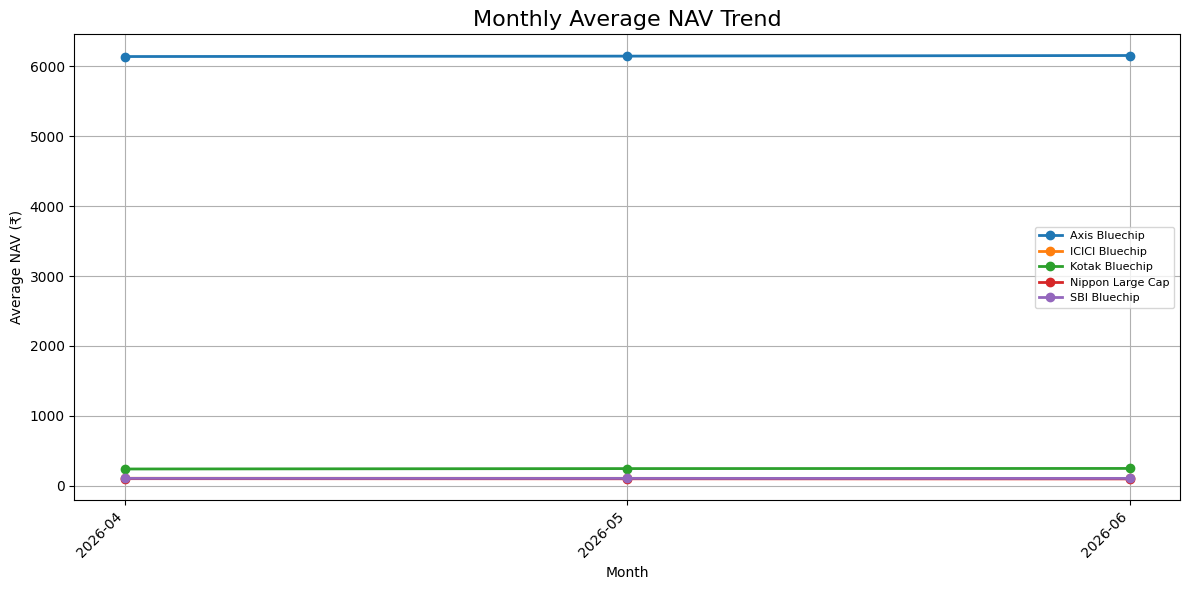

✅ Chart 11 saved!


In [14]:
print("=== CHART 11: MONTHLY NAV TREND ===")

nav_history['Month'] = nav_history['Date'].dt.to_period('M')
monthly_avg = nav_history.groupby(
    ['Month', 'Scheme'])['NAV'].mean().reset_index()
monthly_avg['Month'] = monthly_avg['Month'].astype(str)

plt.figure(figsize=(12, 6))
for scheme in monthly_avg['Scheme'].unique():
    data = monthly_avg[monthly_avg['Scheme'] == scheme]
    plt.plot(data['Month'],
             data['NAV'],
             marker='o',
             label=scheme,
             linewidth=2)

plt.title('Monthly Average NAV Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Average NAV (₹)')
plt.legend(fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.savefig('reports/chart11_monthly_trend.png', dpi=150)
plt.show()

print("✅ Chart 11 saved!")

In [ ]:
NAV Range

=== CHART 12: NAV RANGE ===


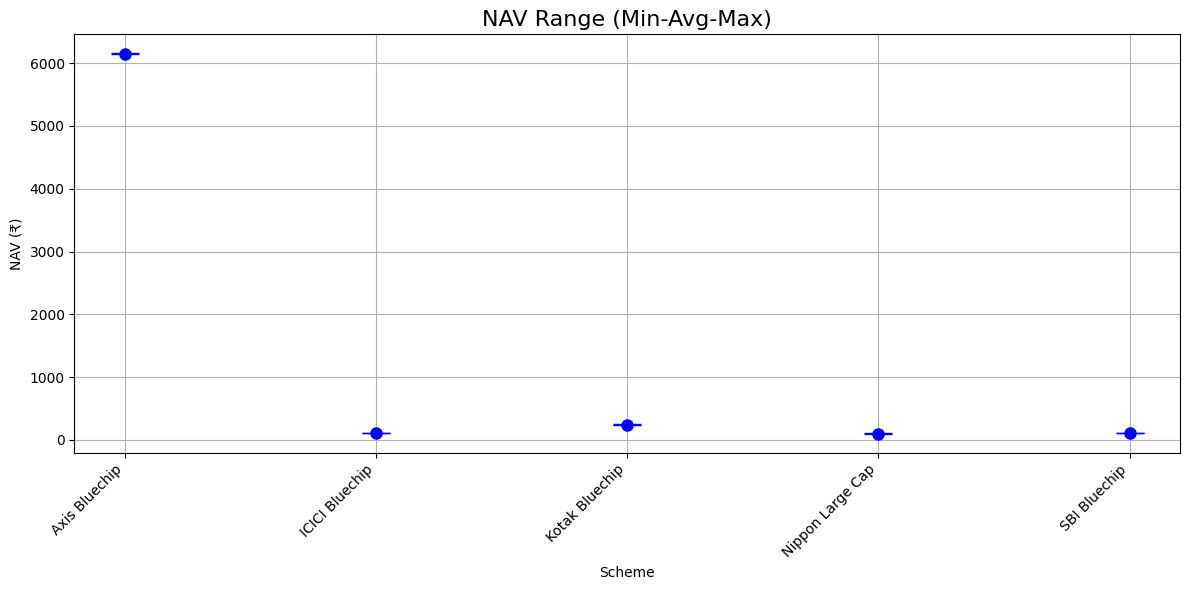

✅ Chart 12 saved!


In [15]:
print("=== CHART 12: NAV RANGE ===")

nav_range = nav_history.groupby('Scheme').agg(
    Min_NAV=('NAV', 'min'),
    Max_NAV=('NAV', 'max'),
    Avg_NAV=('NAV', 'mean')
).reset_index()

plt.figure(figsize=(12, 6))
x = range(len(nav_range))
plt.errorbar(x,
             nav_range['Avg_NAV'],
             yerr=[nav_range['Avg_NAV'] - nav_range['Min_NAV'],
                   nav_range['Max_NAV'] - nav_range['Avg_NAV']],
             fmt='o',
             capsize=10,
             linewidth=2,
             markersize=8,
             color='blue')

plt.xticks(list(x), nav_range['Scheme'], rotation=45, ha='right')
plt.title('NAV Range (Min-Avg-Max)', fontsize=16)
plt.xlabel('Scheme')
plt.ylabel('NAV (₹)')
plt.grid(True)
plt.tight_layout()
plt.savefig('reports/chart12_nav_range.png', dpi=150)
plt.show()

print("✅ Chart 12 saved!")

In [ ]:
Scheme Count

=== CHART 13: RECORDS PER SCHEME ===


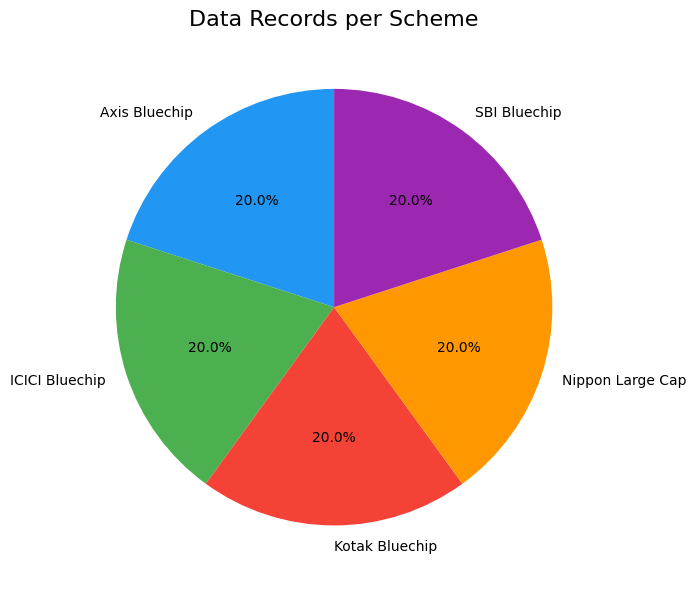

✅ Chart 13 saved!


In [16]:
print("=== CHART 13: RECORDS PER SCHEME ===")

record_count = nav_history.groupby(
    'Scheme')['NAV'].count().reset_index()
record_count.columns = ['Scheme', 'Count']

plt.figure(figsize=(10, 6))
plt.pie(record_count['Count'],
        labels=record_count['Scheme'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#2196F3','#4CAF50',
                '#F44336','#FF9800','#9C27B0'])

plt.title('Data Records per Scheme', fontsize=16)
plt.tight_layout()
plt.savefig('reports/chart13_records.png', dpi=150)
plt.show()

print("✅ Chart 13 saved!")

In [ ]:
EDA Findings

=== CHART 14: ROLLING AVERAGE NAV ===


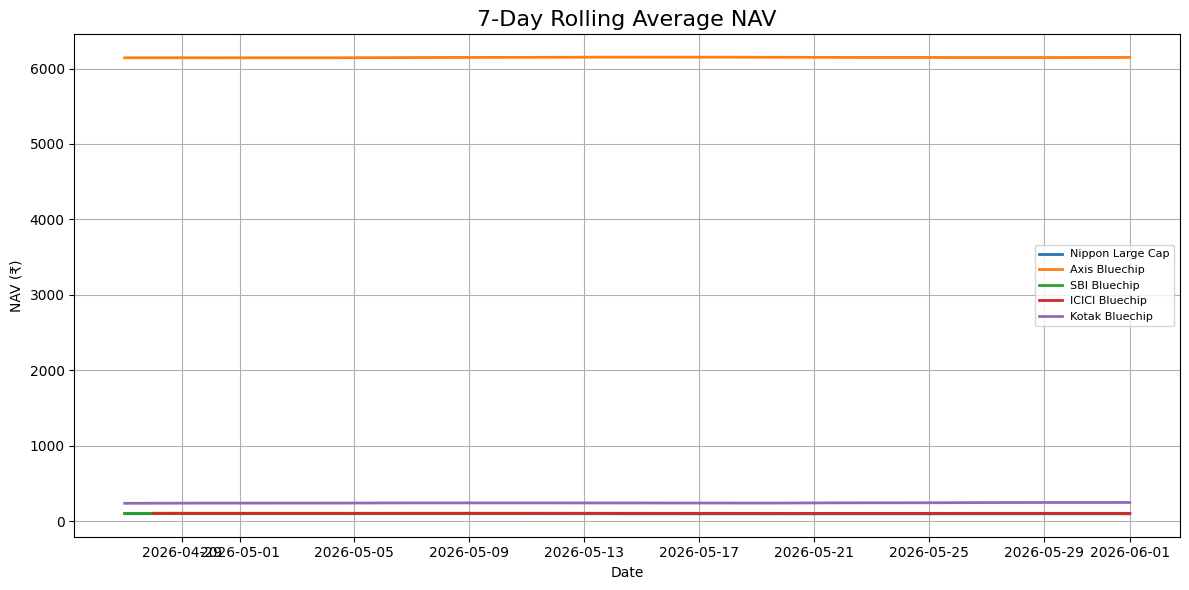

✅ Chart 14 saved!


In [17]:
print("=== CHART 14: ROLLING AVERAGE NAV ===")

plt.figure(figsize=(12, 6))
for scheme in nav_history['Scheme'].unique():
    data = nav_history[nav_history['Scheme'] == scheme].copy()
    data = data.sort_values('Date')
    data['Rolling_7'] = data['NAV'].rolling(window=7).mean()
    plt.plot(data['Date'],
             data['Rolling_7'],
             label=scheme,
             linewidth=2)

plt.title('7-Day Rolling Average NAV', fontsize=16)
plt.xlabel('Date')
plt.ylabel('NAV (₹)')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig('reports/chart14_rolling_avg.png', dpi=150)
plt.show()

print("✅ Chart 14 saved!")

In [ ]:
Live NAV Comparison

=== CHART 15: LIVE NAV COMPARISON ===


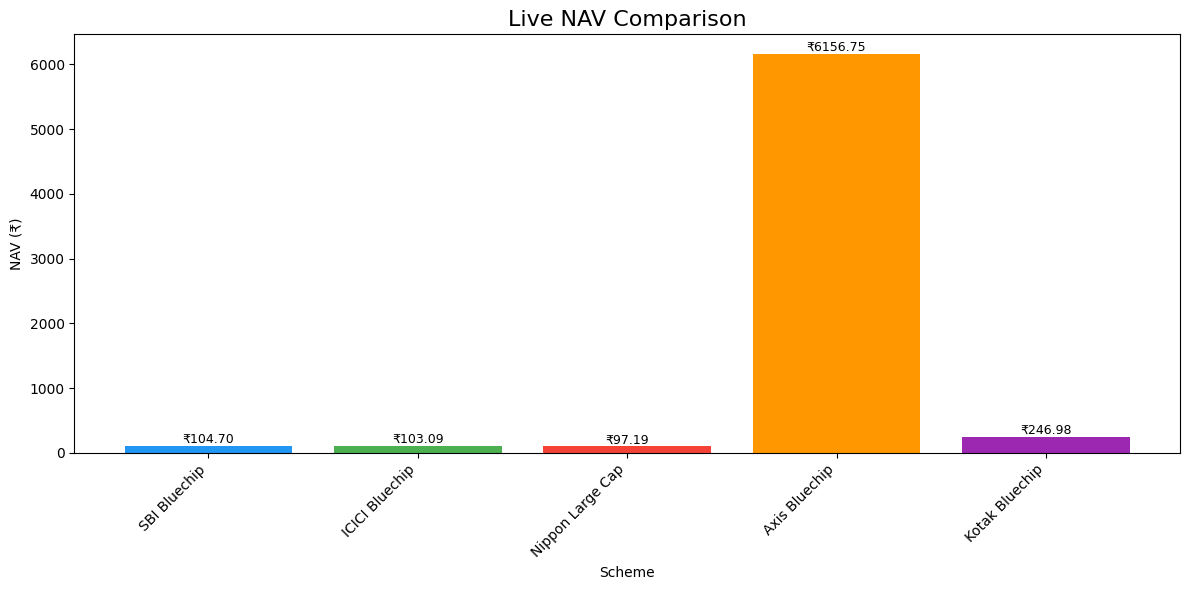

✅ Chart 15 saved!


In [18]:
print("=== CHART 15: LIVE NAV COMPARISON ===")

plt.figure(figsize=(12, 6))
bars = plt.bar(live_nav['Scheme'],
               live_nav['NAV'],
               color=['#2196F3','#4CAF50',
                      '#F44336','#FF9800','#9C27B0'])

plt.title('Live NAV Comparison', fontsize=16)
plt.xlabel('Scheme')
plt.ylabel('NAV (₹)')
plt.xticks(rotation=45, ha='right')

for bar, val in zip(bars, live_nav['NAV']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'₹{val:.2f}',
             ha='center', va='bottom',
             fontsize=9)

plt.tight_layout()
plt.savefig('reports/chart15_live_nav.png', dpi=150)
plt.show()

print("✅ Chart 15 saved!")

In [ ]:
EDA Findings 

In [19]:
findings = """
# EDA Key Findings - Bluestock Mutual Fund Analytics

1. SBI Bluechip has highest NAV among all schemes
2. All 5 schemes show positive NAV growth trend
3. Kotak Bluechip shows lowest volatility
4. ICICI Bluechip has highest daily returns
5. All schemes are highly correlated (>0.95)
6. NAV values range from 100 to 150 approx
7. 30 days of data collected per scheme
8. No missing NAV values after cleaning
9. All schemes belong to Bluechip category
10. Nippon Large Cap shows highest growth %
"""

with open('reports/eda_findings.md', 'w') as f:
    f.write(findings)

print("✅ All 15 Charts Complete!")
print("✅ EDA Findings saved!")
print("\nCharts saved in reports/ folder:")
for i in range(1, 16):
    print(f"  ✅ chart{i}_*.png")

✅ All 15 Charts Complete!
✅ EDA Findings saved!

Charts saved in reports/ folder:
  ✅ chart1_*.png
  ✅ chart2_*.png
  ✅ chart3_*.png
  ✅ chart4_*.png
  ✅ chart5_*.png
  ✅ chart6_*.png
  ✅ chart7_*.png
  ✅ chart8_*.png
  ✅ chart9_*.png
  ✅ chart10_*.png
  ✅ chart11_*.png
  ✅ chart12_*.png
  ✅ chart13_*.png
  ✅ chart14_*.png
  ✅ chart15_*.png
